In [1]:
!mkdir levels

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.9 MB/s eta 0:00:00


In [96]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, global_mean_pool
import torch.nn.functional as F
from torch.nn import Linear

import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
import random
import importlib
import game
importlib.reload(game)
from copy import deepcopy

## Forward Agent

In [172]:
class GraphSAGENet(torch.nn.Module):
    def __init__(self):
        self.num_embeddings = 8
        self.embedding_dim = 3
        self.in_channels = 4 # number of boxes in level + embedding dim
        self.hidden_channels=18
        self.out_channels=1
        super(GraphSAGENet, self).__init__()
        self.embedding_layer = nn.Embedding(self.num_embeddings, self.embedding_dim)
        self.conv1 = SAGEConv(self.in_channels, self.hidden_channels)
        self.conv2 = SAGEConv(self.hidden_channels, self.hidden_channels)
        self.conv3 = SAGEConv(self.hidden_channels, self.hidden_channels)
        self.lin1 = Linear(self.hidden_channels, self.hidden_channels)
        self.lin2 = Linear(self.hidden_channels, self.out_channels)

        # Optimistic Initialization
        # self.init_optimistic_weights(self.lin, init_value=1.05)

    def forward(self, data):
        x, edge_list = data.x, data.edge_list
        node_indices = x[:, 0].long()
        mask = node_indices.view((-1,1))[:,0] != game.GameElements.FLOOR.value
        embedded_features = self.embedding_layer(node_indices)
        x = torch.cat([embedded_features, x[:, 1:]], dim=1)
        x = self.conv1(x, edge_list)
        x = F.relu(x)
        x = self.conv2(x, edge_list)
        x = F.relu(x)
        x = self.conv3(x, edge_list)
        x = F.relu(x)
        x = x[mask]
        x = global_mean_pool(x, data.batch)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

    def init_optimistic_weights(self, layer, init_value=1.05):
        with torch.no_grad():
            layer.bias.fill_(init_value)
            layer.weight.fill_(0.01)

In [161]:
class ForwardAgent():
  def __init__(self, lr=0.001):
    self.value_network = GraphSAGENet()
    self.optimizer = optim.Adam(self.value_network.parameters(), lr=lr)
    self.loss = nn.MSELoss()
    self.alpha = 0.1
    self.eps = 0.2
    self.gamma = 0.8

  def policy(self, env):
    self.value_network.eval()
    legal_moves = env.legal_moves()
    assert len(legal_moves), "agent is stuck"
    value_moves = []
    for char in legal_moves:
        nodes, reward, done = env.step(char)
        data = Data(x=nodes, edge_list=env.edge_list)
        value_moves.append([char, nodes, reward, done, self.value_network(data)])
    return max(value_moves, key=lambda x:x[4])

  def random_policy(self, env):
    legal_moves = env.legal_moves()
    if len(legal_moves)==0:
      return None
    else:
      return random.choice(legal_moves)

  def random_baseline(self, number_of_episodes, start, end, plot=True):
    wins=[0 for i in range(number_of_episodes)]
    moves=[]
    for episode in tqdm(range(number_of_episodes)):
        # create new game instance
        ind = random.randint(start, end)
        env = game.Game(level_id=ind, disable_prints=True)
        if episode % 100 == 0:
            moves.append(env.player_position)
        nodes, reward, done = env.state()
        while not done:
          action = self.random_policy(env)
          if episode % 100 == 0:
            moves.append(action)
          if action != None:
            nodes, reward, done = env.play(action)
            wins[episode] = wins[episode] + reward
          else:
            done = 1
    if plot:
      plt.plot([sum(wins[:i])/number_of_episodes for i in range(number_of_episodes)], label="forward random policy")
      plt.legend()
    print(f"forward agent in [{start}, {end}] random policy solved: {sum(wins)/number_of_episodes}, {sum(wins)}/{number_of_episodes}")

  def train(self, number_of_episodes, start, end, plot=True):
      wins = [0 for _ in range(number_of_episodes)]
      moves = []

      for episode in tqdm(range(number_of_episodes)):
          ind = random.randint(start, end)
          # Initialize the game
          env = game.Game(level_id=ind, disable_prints=True)
          edges = env.edge_list
          if episode % 100 == 0 or episode == number_of_episodes-1:
              moves.append(env.player_position)

          nodes, reward, done = env.state()
          while not done:
              # Choose action
              action, next_nodes, reward, done = self.choose_action(env)
              # TD(0) update
              self.update_agent(nodes, next_nodes, edges,reward, done)

              # Update game state if action is chosen
              if action is not None:
                  nodes, reward, done = env.play(action)
                  assert torch.equal(next_nodes, nodes), "nodes mismatch after action"
                  if reward != 0:
                    assert done, "Received reward but did not terminate"
              wins[episode] += reward
              node = next_nodes

              if episode % 100 == 0 or episode == number_of_episodes-1:
                  moves.append(action)

      if plot:
          #plt.plot([sum(wins[:i])/number_of_episodes for i in range(number_of_episodes)], label="forward greedy policy")
          plt.scatter([i for i in range(len(wins))], wins, label="forward greedy policy")
          plt.legend()
          file_path = "forward_run.json"
          json_data = json.dumps(moves)
          with open(file_path, "w") as file:
              file.write(json_data)

      print(f"forward agent in [{start}, {end}] greedy policy solved: {sum(wins)/number_of_episodes}, {sum(wins)}/{number_of_episodes}")
      return wins, moves

  def choose_action(self, env):
    action, next_nodes, next_reward, next_done = None, None, None, None
    legal_moves = env.legal_moves()
    # agent is stuck and can't move
    if len(legal_moves) == 0:
      next_nodes, next_reward, next_done = env.state()
      next_done=1
    # exploration
    elif np.random.rand() < self.eps:
      action = random.choice(legal_moves)
      next_nodes, next_reward, next_done = env.step(action)
    # exploitation
    else:
      [action, next_nodes, next_reward, next_done, _] = self.policy(env)
    return action, next_nodes, next_reward, next_done

  def update_agent(self, nodes, next_nodes, edges, reward, done):

    data = Data(x=nodes, edge_list=edges)
    next_data = Data(x=next_nodes, edge_list=edges)

    value = self.value_network(data)
    next_value = self.value_network(next_data)
    # TD(0) update: V(s)←V(s)+α(R+γV(s')−V(s))
    target = value + self.alpha*(reward + self.gamma*next_value.detach()*(1-done) - value) # using detach here to exclude prediction from computation graph as is standard in TD(0)
    # calculate loss
    loss = self.loss(value, target.detach())
    # optimize
    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()



100%|██████████| 200/200 [00:08<00:00, 23.81it/s]


forward agent in [0, 0] greedy policy solved: 1.0, 200/200


100%|██████████| 400/400 [00:41<00:00,  9.66it/s]


forward agent in [1, 1] greedy policy solved: 1.0, 400/400
[[3, 1], 'w', 'w', 'd', 'd', 's', 'w', 's', 's', 's', 'w', 's', 's', 'd', 'd', 'w', 'w', 'w', [3, 1], 'w', 'w', 'd', 'd', 's', 's', 's', 'w', 's', 's', 'd', 'd', 'w', 's', 'w', 'w', 'w', [3, 1], 'w', 's', 'w', 'w', 'd', 'd', 's', 'w', 's', 's', 's', 'w', 's', 's', 'd', 'a', 'd', 'd', 'w', 'w', 'w', [3, 1], 'w', 'w', 'd', 'd', 's', 's', 's', 's', 'w', 's', 'd', 'd', 'w', 'w', 's', 'w', 'w', [3, 1], 's', 'w', 'w', 'w', 'd', 'd', 's', 's', 's', 'w', 's', 's', 'd', 'd', 'w', 'w', 's', 'w', 'w']


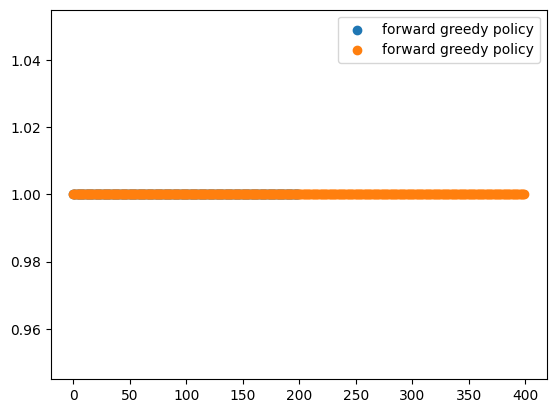

In [171]:
torch.manual_seed(40)
random.seed(40)
np.random.seed(40)
forwardagent = ForwardAgent()
wins, moves = forwardagent.train(number_of_episodes=200, start=0, end=0)
wins, moves = forwardagent.train(number_of_episodes=400, start=1, end=1)
print(moves)

100%|██████████| 200/200 [02:39<00:00,  1.25it/s]

forward agent in [0, 0] greedy policy solved: 0.03, 6/200


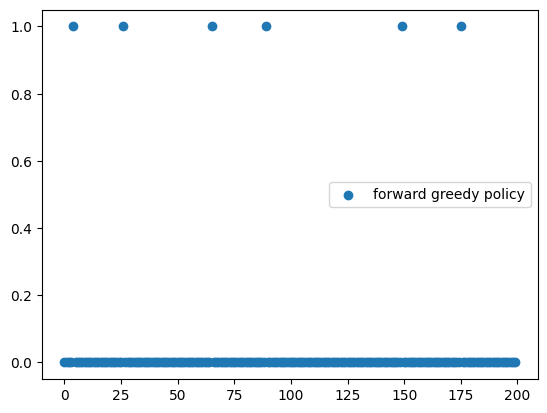

100%|██████████| 200/200 [00:07<00:00, 25.43it/s]


forward agent in [0, 0] random policy solved: 0.755, 151/200


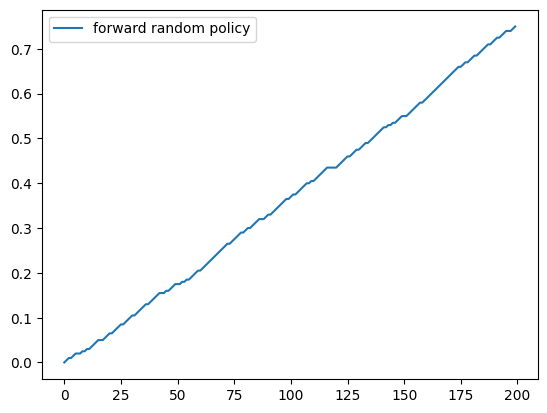

In [103]:
for lr in [0.0001]:
  torch.manual_seed(40)
  random.seed(40)
  np.random.seed(40)
  forwardagent = ForwardAgent(lr=lr)
  forwardagent.train(number_of_episodes=200, start=0, end=0)
  plt.show()

forwardagent = ForwardAgent()
forwardagent.random_baseline(number_of_episodes=200, start=0, end=0)

i: 0


100%|██████████| 12/12 [00:02<00:00,  5.43it/s]


backward agent in [0, 0] greedy policy solved: 0.9166666666666666, 11/12


100%|██████████| 12/12 [00:02<00:00,  5.91it/s]


forward agent in [0, 0] greedy policy solved: 0.9166666666666666, 11/12


...

backward agent in [9, 9] greedy policy solved: 0.84, 21/25


100%|██████████| 100/100 [01:14<00:00,  1.33it/s]


forward agent in [9, 9] greedy policy solved: 0.0, 0/100


100%|██████████| 100/100 [00:05<00:00, 19.77it/s]


forward agent in [9, 9] random policy solved: 0.0, 0/100


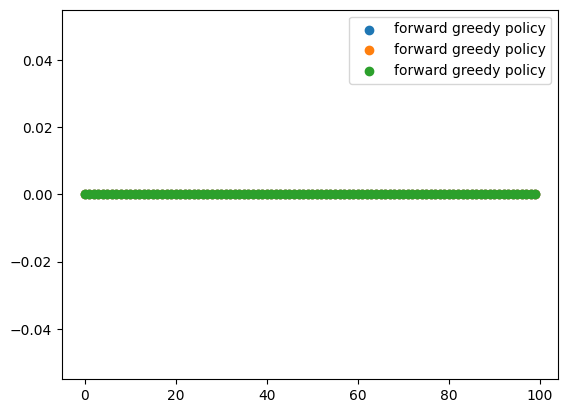

In [ ]:
# TODO: it seems like if the agent does not find the goal in the first iteration, its value function converges to a undesirable stationary function
torch.manual_seed(40)
random.seed(40)
np.random.seed(40)
for i in range(3):
  print(f"i: {i}")
  forwardagent = ForwardAgent()
  forwardagent.train_backward_agent(number_of_episodes=12, start=0, end=0)
  forwardagent.train(number_of_episodes=12, start=0, end=0, plot=False)
  forwardagent.train_backward_agent(number_of_episodes=25, start=9, end=9)
  forwardagent.train(number_of_episodes=100, start=9, end=9)
baseline = ForwardAgent()
baseline.random_baseline(number_of_episodes=100, start=9, end=9, plot=False)